# 02 - Model Training, Tuning and Validation
Stratified k-fold CV with leakage-safe pipelines. Reports generic classification metrics and the competition Hybrid Score, tunes the top models, tests hypothesis H3, and produces the test submission.

In [1]:
!pip install -q kaggle numpy pandas scikit-learn matplotlib

import sys
from pathlib import Path

# Download datasets (public, no credentials needed)
!kaggle datasets download -d gpla77/zum-pro-data -p /content/data --unzip
!kaggle datasets download -d gpla77/zum-pro-code  -p /content/src_pkg  --unzip

# Verify data files
DATA = Path("/content/data/data")
REQUIRED = ["train.csv", "test.csv", "sample_submission.csv", "metaData.csv"]
missing = [f for f in REQUIRED if not (DATA / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing data files: {missing}")
print("Data OK:", [f for f in REQUIRED])

# Verify src module
SRC = Path("/content/src_pkg")
src_files = ["utils.py", "data_loader.py", "preprocessing.py", "models.py", "evaluation.py"]
missing_src = [f for f in src_files if not (SRC / "src" / f).exists()]
if missing_src:
    raise FileNotFoundError(f"Missing src files: {missing_src}")
print("Src OK:", src_files)

sys.path.insert(0, str(SRC))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils import set_global_seed, HORIZONS, save_figure, save_table
from src import data_loader as dl, preprocessing as pp, models as M, evaluation as ev
set_global_seed()
print("Setup complete, ROOT:", SRC, "| DATA:", DATA)

Dataset URL: https://www.kaggle.com/datasets/gpla77/zum-pro-data
License(s): unknown
100% 27.9k/27.9k [00:00<00:00, 19.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/gpla77/zum-pro-code
License(s): unknown
100% 8.54k/8.54k [00:00<00:00, 21.9MB/s]

Data OK: ['train.csv', 'test.csv', 'sample_submission.csv', 'metaData.csv']
Src OK: ['utils.py', 'data_loader.py', 'preprocessing.py', 'models.py', 'evaluation.py']
Setup complete, ROOT: /content/src_pkg | DATA: /content/data/data


In [2]:
train, test, submission, meta = dl.load_raw(folder=DATA)
features = dl.feature_columns(train)
N_SPLITS = 5
FAST = False
all_models = M.get_models(fast=FAST)
prep = lambda: pp.build_preprocessor(use_interactions=True, scale=True)
print('models:', list(all_models))

models: ['logistic_regression', 'decision_tree', 'random_forest', 'gradient_boosting', 'svm', 'knn']


## Generic per-horizon classification (stratified CV)

In [3]:
summary, oof = ev.evaluate_models_per_horizon(all_models, prep, train, features, n_splits=N_SPLITS)
save_table(summary, 'cv_generic_summary.csv')
summary.pivot(index='model', columns='horizon_h', values='roc_auc').round(3)

horizon_h,12,24,48,72
model,,,,
decision_tree,0.837,0.918,0.975,1.000
gradient_boosting,0.958,0.988,0.989,1.000
knn,0.756,0.804,0.799,0.748
logistic_regression,0.904,0.894,0.904,0.891
random_forest,0.947,0.983,0.992,1.000
svm,0.849,0.855,0.845,0.850


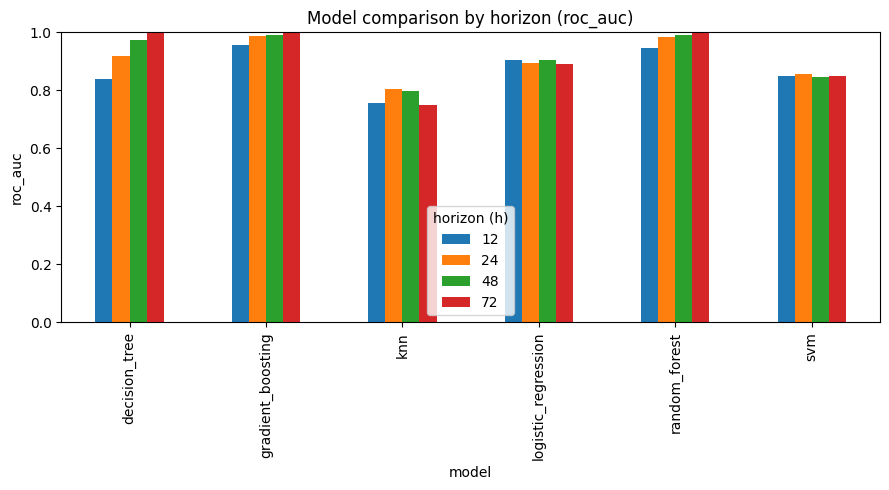

In [4]:
fig = ev.plot_model_comparison(summary, 'roc_auc'); save_figure(fig, 'model_comparison_rocauc.png'); plt.show()

## Competition Hybrid Score per model
Shared stratified CV produces out-of-fold horizon probabilities for every fire; from these we compute C-index, Weighted Brier and the Hybrid Score.

In [5]:
from sklearn.base import clone
comp_rows = []
for name, cfg in all_models.items():
    sc, _ = ev.competition_cv(lambda h, e=cfg['estimator']: clone(e),
                              prep, train, features, n_splits=N_SPLITS)
    comp_rows.append({'model': name, 'hybrid': sc['hybrid'], 'c_index': sc['c_index'],
                      'weighted_brier': sc['weighted_brier']})
comp = pd.DataFrame(comp_rows).sort_values('hybrid', ascending=False).reset_index(drop=True)
save_table(comp, 'cv_competition_summary.csv'); comp.round(4)

,model,hybrid,c_index,weighted_brier
0,gradient_boosting,0.9701,0.9335,0.0142
1,decision_tree,0.9630,0.9186,0.0179
2,random_forest,0.9476,0.9299,0.0448
3,logistic_regression,0.8689,0.8519,0.1237
4,svm,0.8363,0.8133,0.1538
5,knn,0.7963,0.7496,0.1837


## Hyperparameter tuning of the top models
The best models by Hybrid Score are tuned per horizon with `GridSearchCV` (stratified, scoring = ROC-AUC), then re-scored with the competition metric.

In [6]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
TOP_K = 2 if FAST else 3
top_models = comp['model'].head(TOP_K).tolist()
print('tuning:', top_models)
tuned_best = {}
for name in top_models:
    per_h = {}
    for h in HORIZONS:
        X, y = dl.make_horizon_dataset(train, h, features)
        pipe = Pipeline([('pre', prep()), ('model', clone(all_models[name]['estimator']))])
        cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
        gs = GridSearchCV(pipe, all_models[name]['param_grid'], scoring='roc_auc', cv=cv, n_jobs=-1)
        gs.fit(X, y)
        per_h[h] = gs.best_estimator_.named_steps['model']
    tuned_best[name] = per_h
print('done')

tuning: ['gradient_boosting', 'decision_tree', 'random_forest']
done


In [7]:
tuned_rows = []
for name, per_h in tuned_best.items():
    sc, _ = ev.competition_cv(lambda h, ph=per_h: clone(ph[h]), prep, train, features, n_splits=N_SPLITS)
    tuned_rows.append({'model': name+' (tuned)', 'hybrid': sc['hybrid'],
                       'c_index': sc['c_index'], 'weighted_brier': sc['weighted_brier']})
tuned = pd.DataFrame(tuned_rows).sort_values('hybrid', ascending=False).reset_index(drop=True)
save_table(tuned, 'cv_tuned_summary.csv'); tuned.round(4)

,model,hybrid,c_index,weighted_brier
0,decision_tree (tuned),0.9699,0.9348,0.0151
1,gradient_boosting (tuned),0.9637,0.9381,0.0253
2,random_forest (tuned),0.9478,0.9317,0.0453


Best hyperparameters per horizon for the top model:

In [8]:
best_name = tuned.iloc[0]['model'].replace(' (tuned)', '')
best_params = {h: {k: v for k, v in tuned_best[best_name][h].get_params().items()
                   if k in all_models[best_name]['estimator'].get_params() and k not in ('random_state','n_jobs')}
               for h in HORIZONS}
for h, p in best_params.items():
    print(h, 'h ->', {k: v for k, v in p.items() if k in ['C','penalty','n_estimators','max_depth','learning_rate','min_samples_leaf','n_neighbors','kernel','weights']})

12 h -> {'max_depth': 3, 'min_samples_leaf': 10}
24 h -> {'max_depth': 3, 'min_samples_leaf': 10}
48 h -> {'max_depth': 3, 'min_samples_leaf': 10}
72 h -> {'max_depth': 3, 'min_samples_leaf': 1}


## H3: do higher-order interaction features help?

In [9]:
h3 = []
for flag in [False, True]:
    sc, _ = ev.competition_cv(lambda h: clone(all_models['logistic_regression']['estimator']),
                              lambda f=flag: pp.build_preprocessor(use_interactions=f, scale=True),
                              train, features, n_splits=N_SPLITS)
    h3.append({'interactions': flag, 'hybrid': sc['hybrid'], 'c_index': sc['c_index'],
               'weighted_brier': sc['weighted_brier']})
h3 = pd.DataFrame(h3); save_table(h3, 'h3_interactions.csv'); h3.round(4)

,interactions,hybrid,c_index,weighted_brier
0,False,0.8701,0.8535,0.1228
1,True,0.8689,0.8519,0.1237


## Final model and submission
Fit the best tuned model per horizon on the full training data, predict the four horizon probabilities for the test set (monotonic across horizons), and write the submission.

In [12]:
best_per_h = tuned_best[best_name]
fitted = ev.fit_horizon_models(lambda h: clone(best_per_h[h]), prep, train, features)
sub = ev.make_submission(fitted, test[features], test['event_id'])
save_table(sub, 'submission.csv')
print('best model:', best_name); print(sub.head())

best model: decision_tree
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.000000       0.0       0.0       0.0
1  13353600  0.619048       1.0       1.0       1.0
2  13942327  0.000000       0.0       0.0       0.0
3  16112781  0.619048       1.0       1.0       1.0
4  17132808  0.000000       0.0       0.0       0.0


In [13]:
import joblib, json, zipfile
from pathlib import Path

SAVE_DIR = Path("/content/dt_models")
SAVE_DIR.mkdir(exist_ok=True)

for h, pipeline in fitted.items():
    joblib.dump(pipeline, SAVE_DIR / f"dt_{h}h.joblib")
    print(f"Saved: dt_{h}h.joblib")

json.dump(features, open(SAVE_DIR / "feature_names.json", "w"))

best_params = {str(h): model.get_params() for h, model in best_per_h.items()}
json.dump(best_params, open(SAVE_DIR / "best_params.json", "w"))

zip_path = Path("/content/dt_models.zip")
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in SAVE_DIR.iterdir():
        zf.write(f, f.name)

print(f"\nDone: {zip_path}")
print("Files in:", [f.name for f in SAVE_DIR.iterdir()])

Saved: dt_12h.joblib
Saved: dt_24h.joblib
Saved: dt_48h.joblib
Saved: dt_72h.joblib

Done: /content/dt_models.zip
Files in: ['feature_names.json', 'dt_48h.joblib', 'dt_72h.joblib', 'dt_24h.joblib', 'dt_12h.joblib', 'best_params.json']
